In [1]:
# Import Libraries
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# simulate data
np.random.seed(42)

# Assume 10,000 visitors each
n_A, p_A = 10000, 0.12  # Variant A: 12% conversion
n_B, p_B = 10000, 0.10  # Variant B: 10% conversion

In [3]:
# simulate number of purchases
success_A = np.random.binomial(n_A, p_A)
success_B = np.random.binomial(n_B, p_B)

In [4]:
# Cal Conversion Rates & 95% CIs

def proportion_ci(successes, n, alpha=0.05):
    p_hat = successes / n
    z = stats.norm.ppf(1 - alpha/2)
    se = np.sqrt(p_hat * (1 - p_hat) / n)
    return p_hat, (p_hat - z * se), (p_hat + z *se)

p_A_hat, ci_low_A, ci_high_A = proportion_ci(success_A, n_A)
p_B_hat, ci_low_B, ci_high_B = proportion_ci(success_B, n_B)

results = pd.DataFrame({
    'Variant':     ['A', 'B'],
    'Visitors':    [n_A, n_B],
    'Conversions': [success_A, success_B],
    'CR (p̂)':      [p_A_hat, p_B_hat],
    'CI Lower (95%)': [ci_low_A, ci_low_B],
    'CI Upper (95%)': [ci_high_A, ci_high_B],
})
print(results)

  Variant  Visitors  Conversions  CR (p̂)  CI Lower (95%)  CI Upper (95%)
0       A     10000         1171   0.1171        0.110798        0.123402
1       B     10000         1004   0.1004        0.094510        0.106290


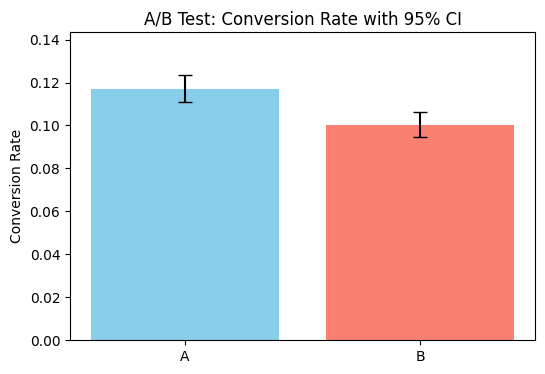

In [5]:
# Plot Conversion Rates with Error Bars
plt.figure(figsize=(6,4))
plt.bar(
    results['Variant'],
    results['CR (p̂)'],
    yerr=[
        results['CR (p̂)'] - results['CI Lower (95%)'],
        results['CI Upper (95%)'] - results['CR (p̂)']
    ],
    capsize=5,
    color=['skyblue', 'salmon']
)
plt.ylabel('Conversion Rate')
plt.title('A/B Test: Conversion Rate with 95% CI')
plt.ylim(0, max(results['CI Upper (95%)']) + 0.02)
plt.show()

In [6]:
# Two-proportion z-test

# Test H0: p_B <= p_A vs H1: p_B > p_A
count = np.array([success_B, success_A])
nobs = np.array([n_B, n_A])

z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')
print(f" Z-statistic: {z_stat: .3f}")
print(f" p-value:     {p_value: .3f}")

if p_value < 0.05:
    print(" → Reject H0: Variant B has a significantly higher conversion rate.")
else:
    print("→ Fail to reject H0: No significant lift from B over A.")

 Z-statistic: -3.793
 p-value:      1.000
→ Fail to reject H0: No significant lift from B over A.


In [7]:
import numpy as np, matplotlib.pyplot as plt, time
from statsmodels.stats.proportion import proportions_ztest
from IPython.display import clear_output

# Use the same true rates from above
true_p_A, true_p_B = 0.10, 0.12
batch_size = 100  # visitors per batch per variant
n_batches = 60    # simulate 60 time steps (e.g. minutes)

# Initiate Counters
n_visits_A = n_visits_B = 0
n_success_A = n_success_B = 0

# List to store metrices for plotting
batches = []
p_value = []
lifts   = []

 Batch 60/60
 Variant A: 6200 visits, 591 buys → CR = 9.532%
 Variant B: 6200 visits, 744 buys → CR = 12.000%
 Observed lift:  2.468%
 z-stat = -3.94, p-value = 1.0000
  → No Significant lift yet.
  → No significant lift yet.


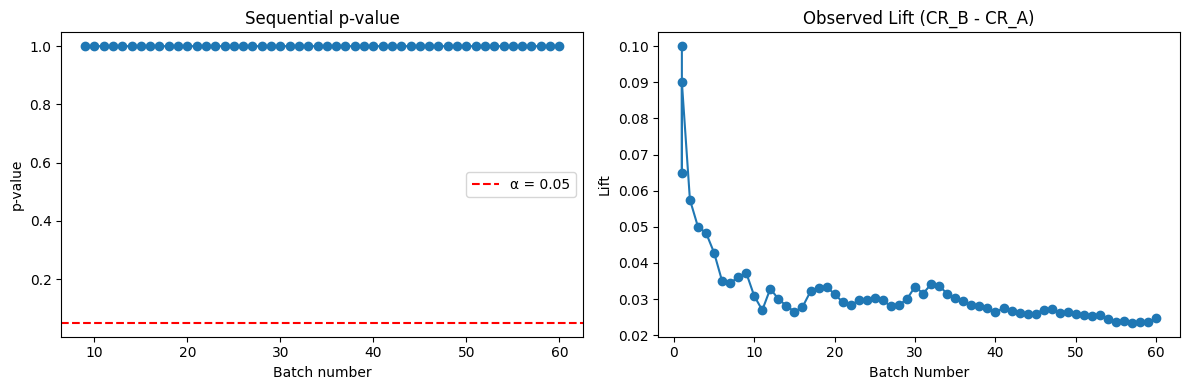

In [15]:
for batch in range(1, n_batches+1):
    # simulate one batch of visitors
    new_A = np.random.binomial(batch_size, true_p_A)
    new_B = np.random.binomial(batch_size, true_p_B)

    # Update totals
    n_visits_A += batch_size
    n_visits_B += batch_size
    n_success_A += new_A
    n_success_B += new_B

    # Compute current conversion rates
    cr_A = n_success_A / n_visits_A
    cr_B = n_success_B / n_visits_B
    lift = cr_B - cr_A

    # Two-proportion z-test (one-sided: B > A)
    counts = np.array([n_success_B, n_success_A])
    nobs   = np.array([n_visits_B, n_visits_A])
    z_stat, p_val = proportions_ztest(count, nobs, alternative='larger')

    # Record for plotting
    batches.append(batch)
    p_value.append(p_val)
    lifts.append(lift)

   # Clear previous output and print current stats
    clear_output(wait=True)
    print(f" Batch {batch}/{n_batches}")
    print(f" Variant A: {n_visits_A} visits, {n_success_A} buys → CR = {cr_A:.3%}")
    print(f" Variant B: {n_visits_B} visits, {n_success_B} buys → CR = {cr_B:.3%}")
    print(f" Observed lift: {lift: .3%}")
    print(f" z-stat = {z_stat:.2f}, p-value = {p_val:.4f}")
    if p_val < 0.05:
        print("  → Significant lift detected (p<0.05).")

    else:
        print("  → No Significant lift yet.")
        
    if p_val < 0.05:
        print("  → Significant lift detected (p<0.05).")

    else:
        print("  → No significant lift yet.")

    # plot p-value and lift over batches
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    axes[0].plot(batches, p_value, '-o')
    axes[0].axhline(0.05, color='red', linestyle='--', label='α = 0.05')
    axes[0].set_title('Sequential p-value')
    axes[0].set_xlabel('Batch number')
    axes[0].set_ylabel('p-value')
    axes[0].legend()

    axes[1].plot(batches, lifts, '-o')
    axes[1].set_title('Observed Lift (CR_B - CR_A)')
    axes[1].set_xlabel('Batch Number')
    axes[1].set_ylabel('Lift')

    plt.tight_layout()
    plt.show()

    # Pause Briefly to simulate real time
    time.sleep(0.9)